In [28]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [94]:
import os
import pandas as pd
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d

# Allow more columns to be displayed
pd.set_option("display.max_columns", None)

import logging
logging.basicConfig(level=logging.WARNING)

In [95]:
!which python

/Users/klemenkubelj/miniconda3/envs/cvar-masters/bin/python


In [96]:
df = pd.read_csv(os.path.join("../data/vloge_processed_2025-05-10.csv"))
print("Original shape:", df.shape)

# df["relative_damage"] = df["SkupnaSkoda"] / df["Vrednost"]
df["relative_damage"] = df["OdstPoskodovanostiObjekta"] / 100
df["Objekt_VisinaVodeM"] = df["Objekt_VisinaVodeCm"] / 100
df = df[df["relative_damage"]<=1]
print("After filtering:", df.shape)

Original shape: (20040, 18)
After filtering: (6440, 20)


In [97]:
df.head()

,VlogaId,Objekt_Naslov,Objekt_Naslov_PostnaStevilka,Objekt_Parcela_Stevilka,Objekt_Parcela_KoId,Objekt_UporabnaPovrsina,Objekt_VisinaVodeCm,Objekt_StopnjaPoskodovanosti,Objekt_CentroidX,Objekt_CentroidY,Skoda_DatumOcene,Objekt_SkodaPovzrocenaVPlazu,Objekt_VrstaObjektaId,DogodekId,Vrednost,OdstPoskodovanostiObjekta,SkupnaSkoda,SkupnaSkodaSource,relative_damage,Objekt_VisinaVodeM
206,149162,Čužnja vas 12,8231 TREBELNO,2501/3,1449,35.00,0.0,NaN,515501.0,85416.0,10/15/10 00:00:00,NaN,2.0,14,3309.35,100.0,3309.35,Postavka3,1.0,0.0
788,155809,Poklek nad Blanco 10,8283 BLANCA,172/0.S,2307,214.54,0.0,NaN,530288.0,97018.0,10/21/10 00:00:00,NaN,2.0,14,72396.27,100.0,72396.27,Postavka3,1.0,0.0
1296,152700,Vrh nad Laškim 3,3270 LAŠKO,187/0.S,1705,161.65,40.0,NaN,521876.0,109619.0,09/28/10 00:00:00,NaN,2.0,14,54338.48,100.0,54338.48,Postavka3,1.0,0.4
1298,157182,Obrežje pri Zidanem Mostu 50,1432 ZIDANI MOST,576/2,1625,196.41,0.0,NaN,513876.0,104422.0,11/04/10 00:00:00,NaN,2.0,14,61876.97,70.0,43313.88,Postavka3,0.7,0.0
1299,157304,Obrežje pri Zidanem Mostu 49,1432 ZIDANI MOST,22/8.S,1625,57.75,0.0,NaN,513884.0,104450.0,11/04/10 00:00:00,NaN,2.0,14,14169.51,100.0,14169.51,Postavka3,1.0,0.0


(0.0, 300.0)

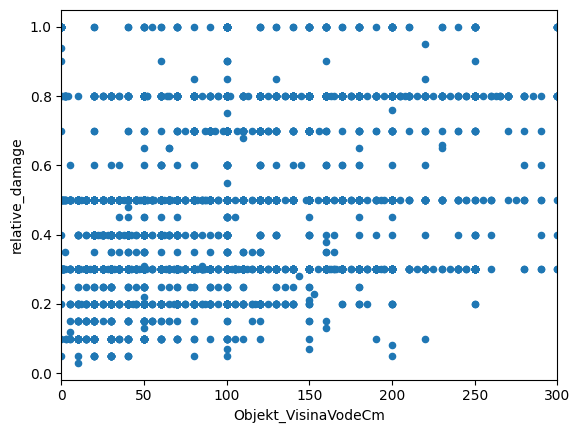

In [98]:

df.plot(x="Objekt_VisinaVodeCm", y="relative_damage", kind="scatter")
plt.xlim(0, 300)

In [166]:
residential_damage_fractions = [
    (0, 0.00),
    (0.5, 0.25),
    (1, 0.40),
    (1.5, 0.50),
    (2, 0.60),
    (2.5, 0.675),
]
industrial_damage_function = [
    (0, 0.00),
    (0.5, 0.15),
    (1, 0.27),
    (1.5, 0.40),
    (2, 0.52),
    (2.5, 0.675),
]
agriculture_damage_function = [
    (0, 0.00), 
    (0.5, 0.30), 
    (1, 0.55), 
    (1.5, 0.65), 
    (2, 0.75), 
    (2.5, 0.80),
]
def plot_violin_damage_by_water_height(df, title: str = ""):
    _df = df.copy()
    total_samples = len(_df)

    # Create water height buckets (every 50cm up to 200cm)
    bucket_edges = np.arange(0, 2.01, 0.5)
    _df["water_height_bucket"] = pd.cut(
        _df["Objekt_VisinaVodeM"], 
        bins=bucket_edges,
        labels=[f"{i}-{i+0.5}m" for i in np.arange(0, 2, 0.5)]
    )

    # Create the figure and axis
    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot violins
    sns.violinplot(
        data=_df,
        x="water_height_bucket",
        y="relative_damage",
        cut=0,  # limit the violin plot to actual data range
        ax=ax  # specify the axis to plot on
    )

    

    # Adjust x-axis to show ticks at the upper bounds of each bucket
    ax.set_xticks(range(len(bucket_edges)-1))
    ax.set_xticklabels([f"{x}m" for x in bucket_edges[1:]])

    # Set y-axis range from 0 to 1
    ax.set_ylim(0, 1)

    # Add count and median annotations for each bucket
    # Calculate and plot median values
    medians = _df.groupby("water_height_bucket")["relative_damage"].median()
    for i, median in enumerate(medians):
        # Add horizontal line for median
        ax.hlines(median, i-0.2, i+0.2, colors="red", linestyles="--", alpha=0.7)

    bucket_counts = _df["water_height_bucket"].value_counts().sort_index()
    for i, (count, median) in enumerate(zip(bucket_counts, medians)):
        ax.text(i, ax.get_ylim()[0], f"n={count}\nmed={median:.2f}", 
                ha="center", va="bottom", 
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))

    # Customize the plot
    ctitle = f"Distribution of Relative Damage by Water Height (Total Samples: {total_samples})"
    if title:
        ctitle += f" - {title}"
    ax.set_title(ctitle)
    ax.set_xlabel("Water Height")
    ax.set_ylabel("Relative Damage")
    ax.tick_params(axis="x", rotation=45)

    # Add grid for better readability
    ax.grid(True, axis="y", linestyle="--", alpha=0.7)
    fig.tight_layout()
    
    return fig, ax

def plot_damage_function(damage_function, color="orange", label="NONE"):
    fig = plt.gcf()
    ax = plt.gca()

    flood_depths = [i[0] for i in damage_function]
    damage_fractions = [i[1] for i in damage_function]

    def get_damage_fraction(depth):
        """
        Get damage fraction for a given flood depth using polynomial interpolation.
        For depths outside the range, we clamp the values to [0, 1].
        
        Args:
            depth (float): Flood depth in meters
            
        Returns:
            float: Damage fraction between 0 and 1
        """
        # Create interpolation function
        f = interp1d(flood_depths, damage_fractions, kind="linear", bounds_error=False, fill_value=(0, 1))
        return float(f(depth))

    # Create points for smooth curve visualization
    depths_smooth = np.linspace(0, 2.5, 100)
    damage_smooth = [get_damage_fraction(d) for d in depths_smooth]

    # Plot the data and fitted curve
    ax.plot([(i - 0.5)*2 for i in flood_depths], damage_fractions, "o", color=color)
    # Dont show this in legend
    ax.plot([(i - 0.5)*2 for i in depths_smooth], damage_smooth, "-", label=label, color=color)
    
    # Set y-axis range from 0 to 1
    # ax.set_ylim(0, 1)
    
    # Add labels and title
    # ax.set_xlabel("Water Height (m)")
    # ax.set_ylabel("Damage Fraction")
    # ax.set_title("Damage Function")
    # ax.grid(True, linestyle="--", alpha=0.7)
    
    
    # Return the figure and axis for further customization
    return fig, ax

/var/folders/ly/jtbv8d056fx1pnpygvdlzn0r0000gn/T/ipykernel_13020/2646682597.py:60: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = _df.groupby("water_height_bucket")["relative_damage"].median()


[]

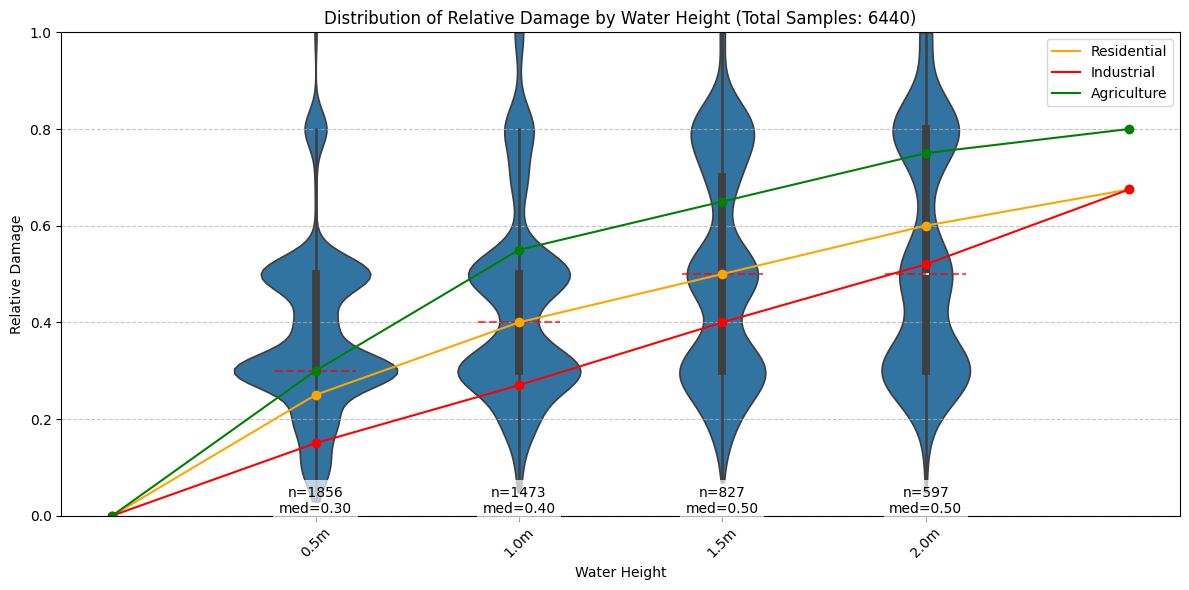

In [167]:
fig, ax = plot_violin_damage_by_water_height(df)
fig, ax = plot_damage_function(residential_damage_fractions, color="orange", label="Residential")
fig, ax = plot_damage_function(industrial_damage_function, color="red", label="Industrial")
fig, ax = plot_damage_function(agriculture_damage_function, color="green", label="Agriculture")
ax.legend()
plt.plot()

Vrste objekta ID: (1,)
----------------------------------------------------------------------------------------------------
Vrste objekta ID: (2,)
----------------------------------------------------------------------------------------------------
Vrste objekta ID: (4,)


/var/folders/ly/jtbv8d056fx1pnpygvdlzn0r0000gn/T/ipykernel_13020/2291650142.py:60: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = _df.groupby("water_height_bucket")["relative_damage"].median()
/var/folders/ly/jtbv8d056fx1pnpygvdlzn0r0000gn/T/ipykernel_13020/2291650142.py:60: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = _df.groupby("water_height_bucket")["relative_damage"].median()
/var/folders/ly/jtbv8d056fx1pnpygvdlzn0r0000gn/T/ipykernel_13020/2291650142.py:60: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observ

----------------------------------------------------------------------------------------------------
Vrste objekta ID: (5,)
----------------------------------------------------------------------------------------------------


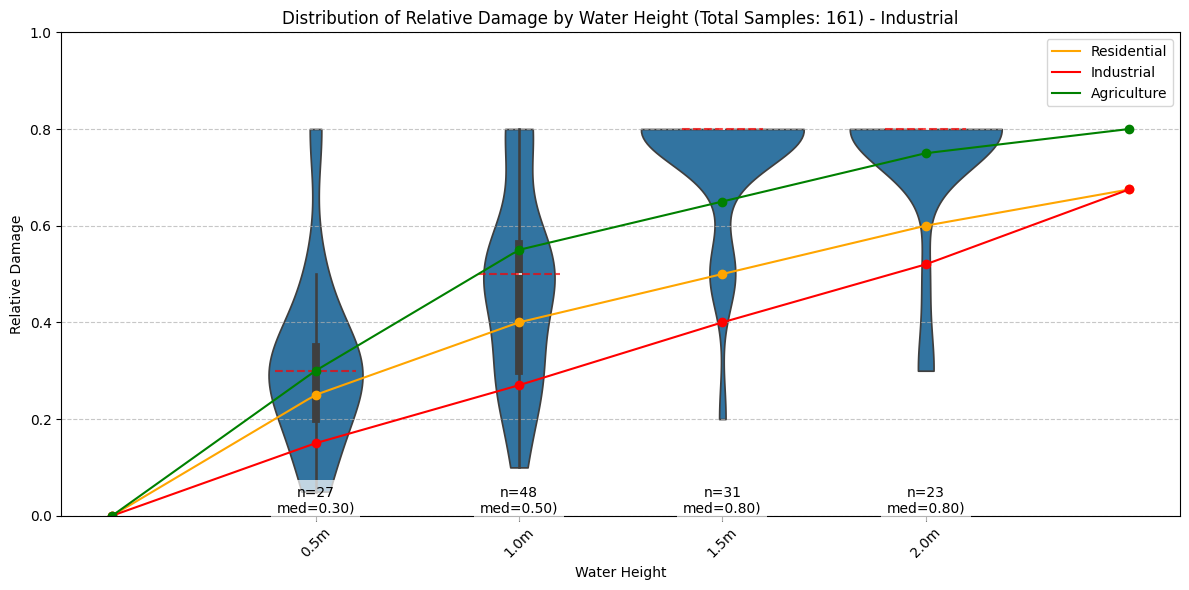

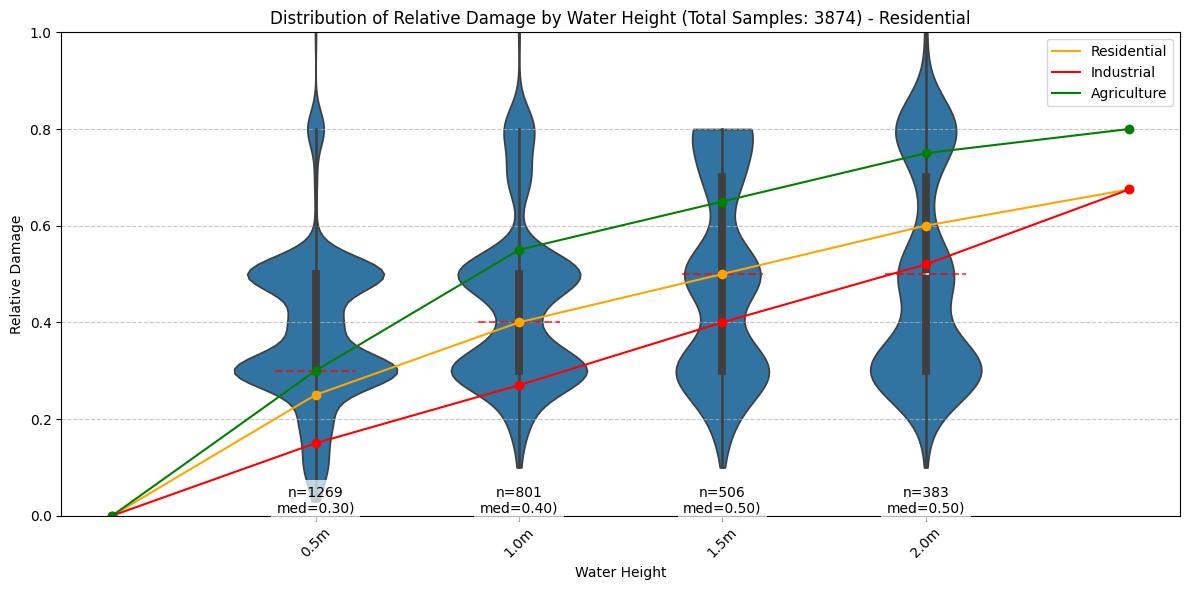

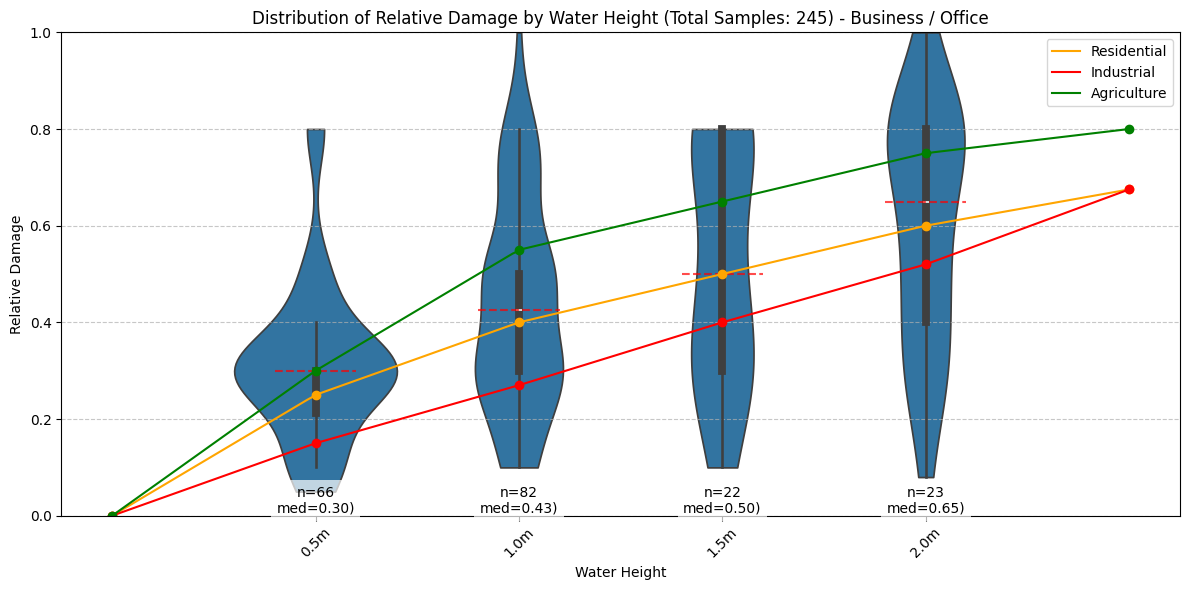

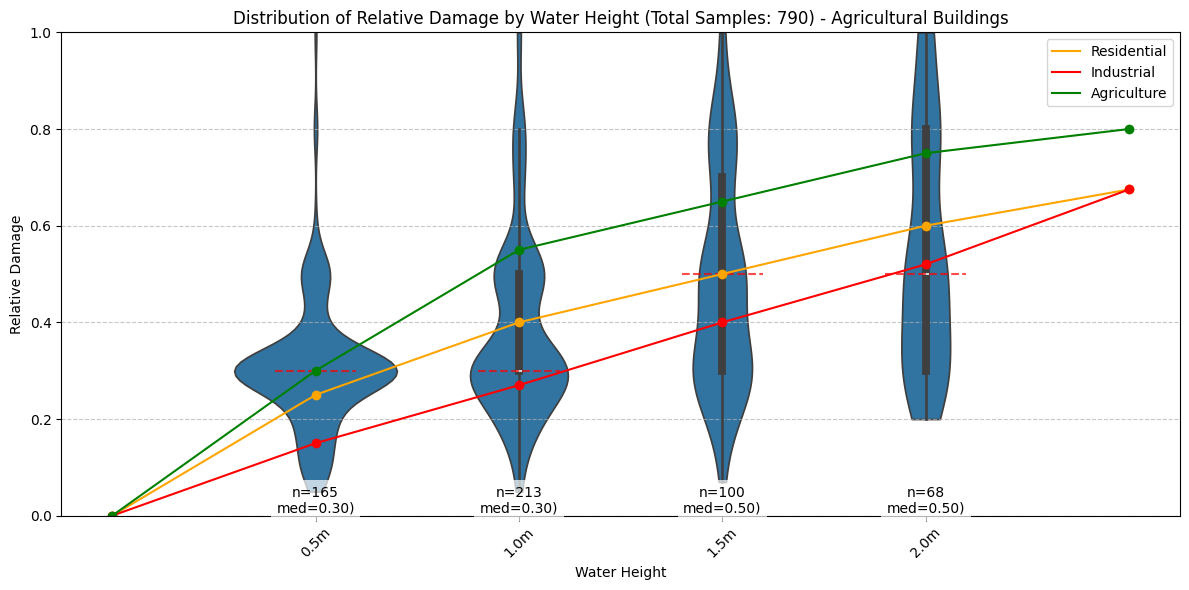

In [165]:

for vrste_objekta_id, title, damage_function in [
    ((1,), "Industrial", residential_damage_fractions),
    ((2,), "Residential", residential_damage_fractions),
    ((4,), "Business / Office", residential_damage_fractions),
    ((5,), "Agricultural Buildings", residential_damage_fractions),
]:
    print(f"Vrste objekta ID: {vrste_objekta_id}")
    _df = df.copy()
    _df = _df[_df["Objekt_VrstaObjektaId"].isin(vrste_objekta_id)]
    # plot_violin_damage_by_water_height(_df)
    fig, ax = plot_violin_damage_by_water_height(_df, title=title)
    fig, ax = plot_damage_function(residential_damage_fractions, color="orange", label="Residential")
    fig, ax = plot_damage_function(industrial_damage_function, color="red", label="Industrial")
    fig, ax = plot_damage_function(agriculture_damage_function, color="green", label="Agriculture")
    ax.legend()
    plt.plot()
    print("-"*100)